In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error

sns.set()

%matplotlib inline

In [2]:
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10

In [3]:
data = pd.read_csv('Temp_and_rain.csv')

In [4]:
data.head()

,tem,Month,Year,rain
0,16.9760,1,1901,18.5356
1,19.9026,2,1901,16.2548
2,24.3158,3,1901,70.7981
3,28.1834,4,1901,66.1616
4,27.8892,5,1901,267.2150


### Data column

In [5]:
data.columns

Index(['tem', 'Month', 'Year', 'rain'], dtype='object')

### Data Shape**

In [6]:
data.shape

(1380, 4)

### year

In [7]:
data['Year'].min(), data['Year'].max()

(1901, 2015)

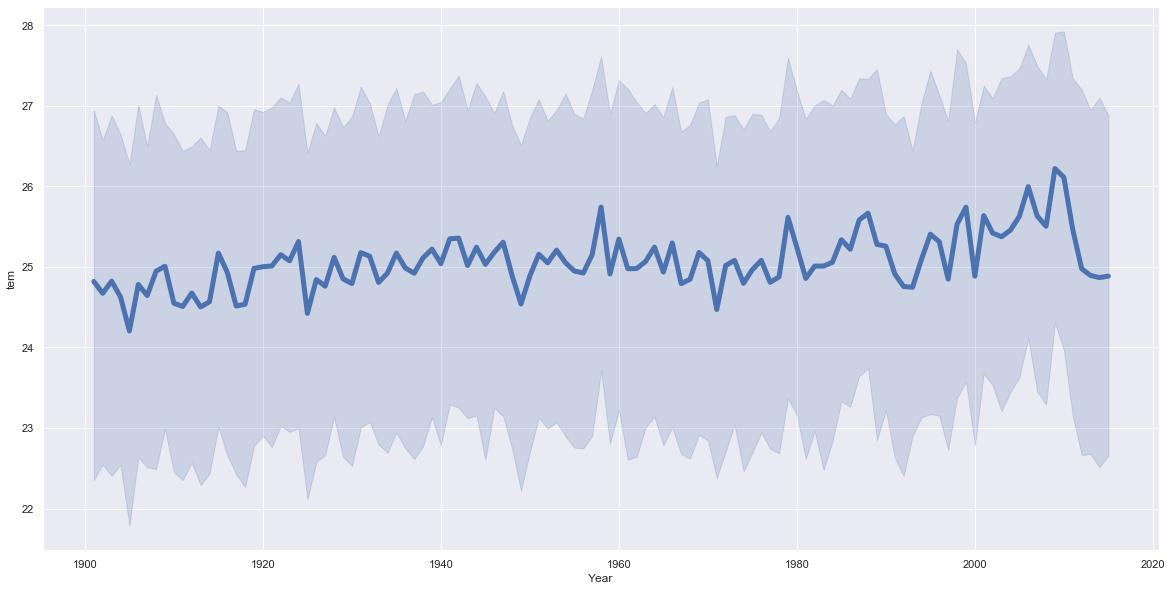

In [8]:
sns.lineplot(x="Year", y="tem",markers=True,lw=5, data=data);

In [9]:
df = data.groupby('Year').tem.mean()

# Moving Average for Trend

In [10]:
def moving_average(series, n):
    """
        Calculate average of last n observations
    """
    return np.average(series[-n:])

In [11]:
def plotMovingAverage(series, window, plot_intervals=False, scale=1.96, plot_anomalies=False):

    """
        series - dataframe with timeseries
        window - rolling window size 
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies 

    """
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(20,10))
    plt.title("Moving average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # Plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")
        
        # Having the intervals, find abnormal values
        if plot_anomalies:
            anomalies = pd.DataFrame(index=series.index, columns=series.values)
            anomalies[series<lower_bond] = series[series<lower_bond]
            anomalies[series>upper_bond] = series[series>upper_bond]
            plt.plot(anomalies, "ro", markersize=10)
        
    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

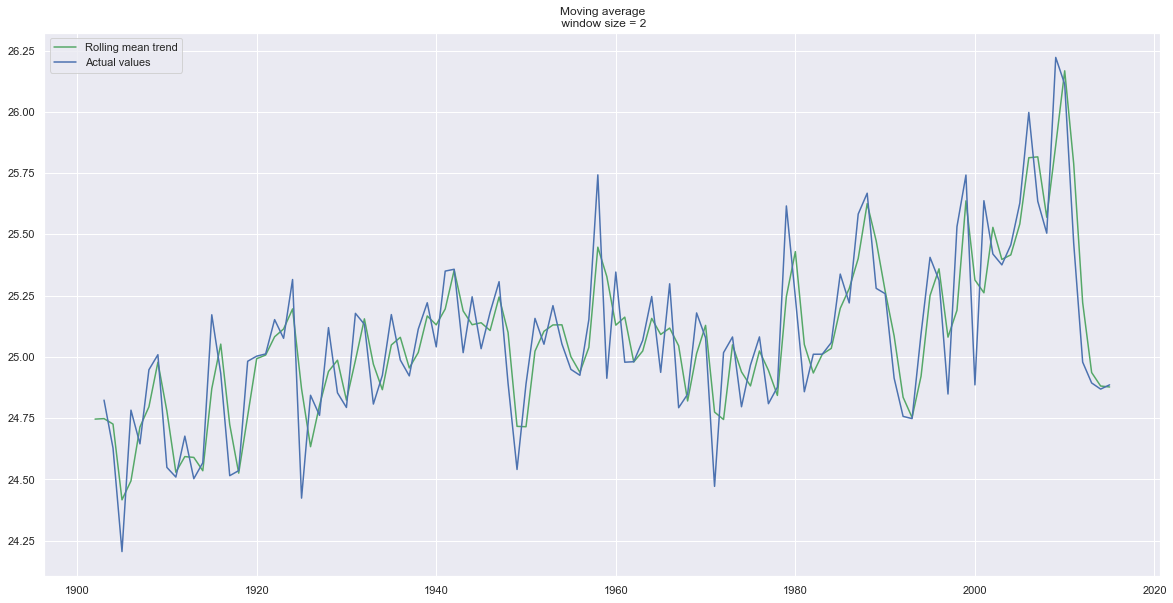

In [12]:
plotMovingAverage(df, 2) 

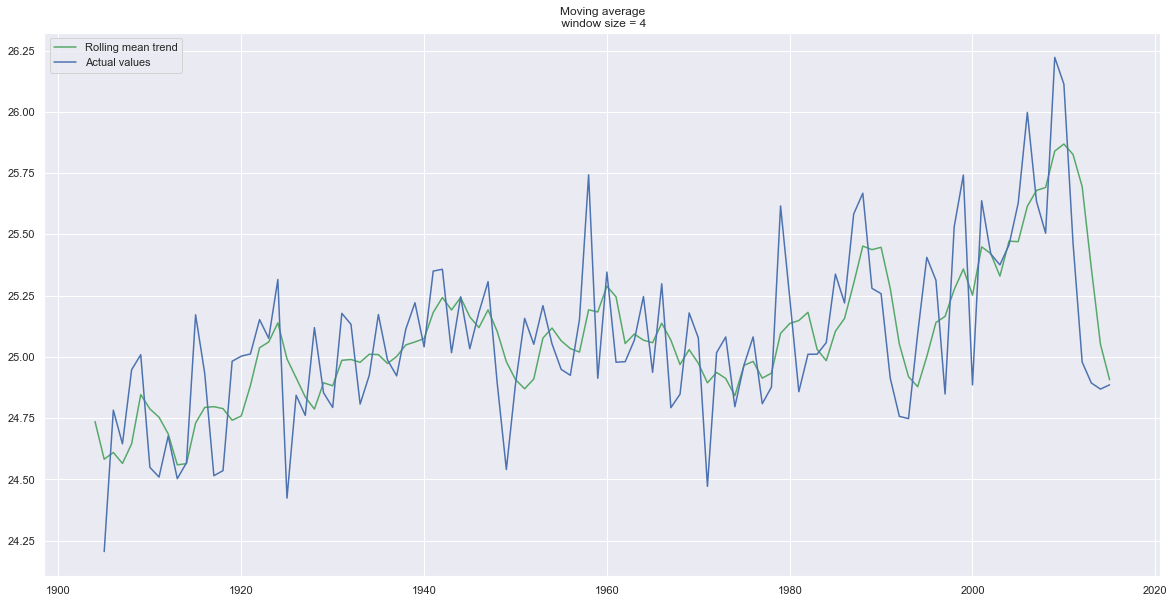

In [13]:
plotMovingAverage(df, 4) 

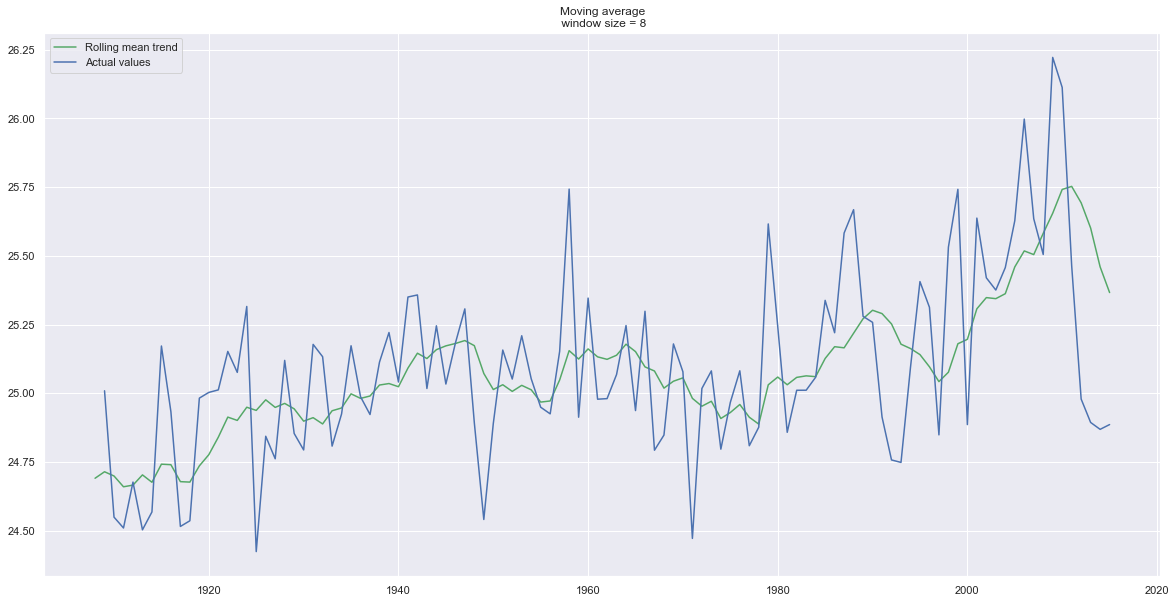

In [14]:
plotMovingAverage(df, 8) 

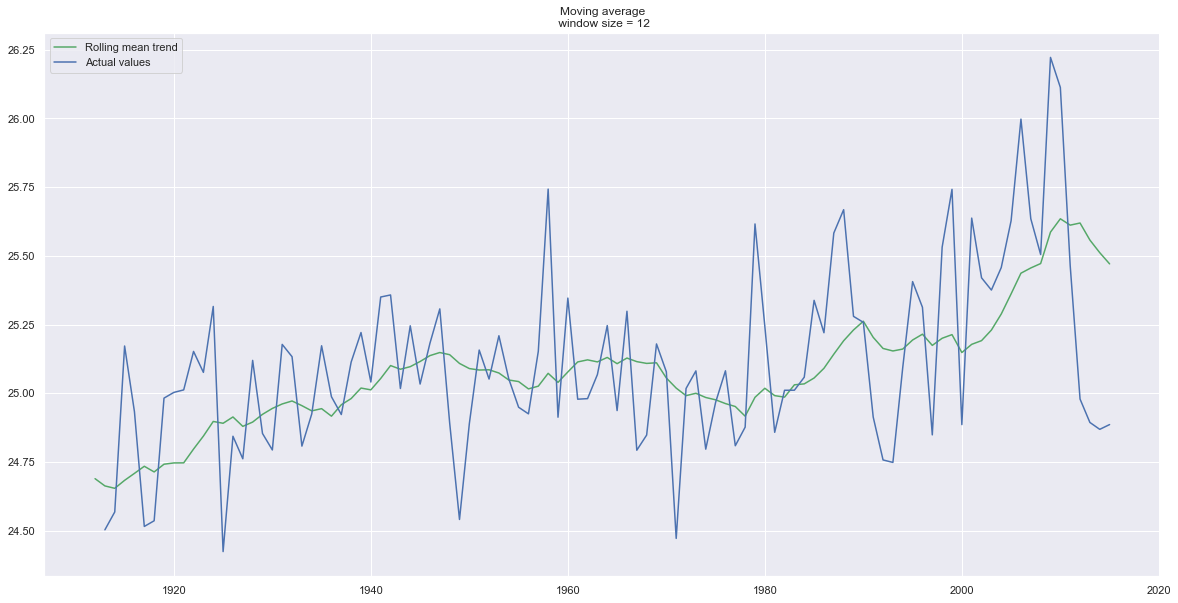

In [15]:
plotMovingAverage(df, 12) 

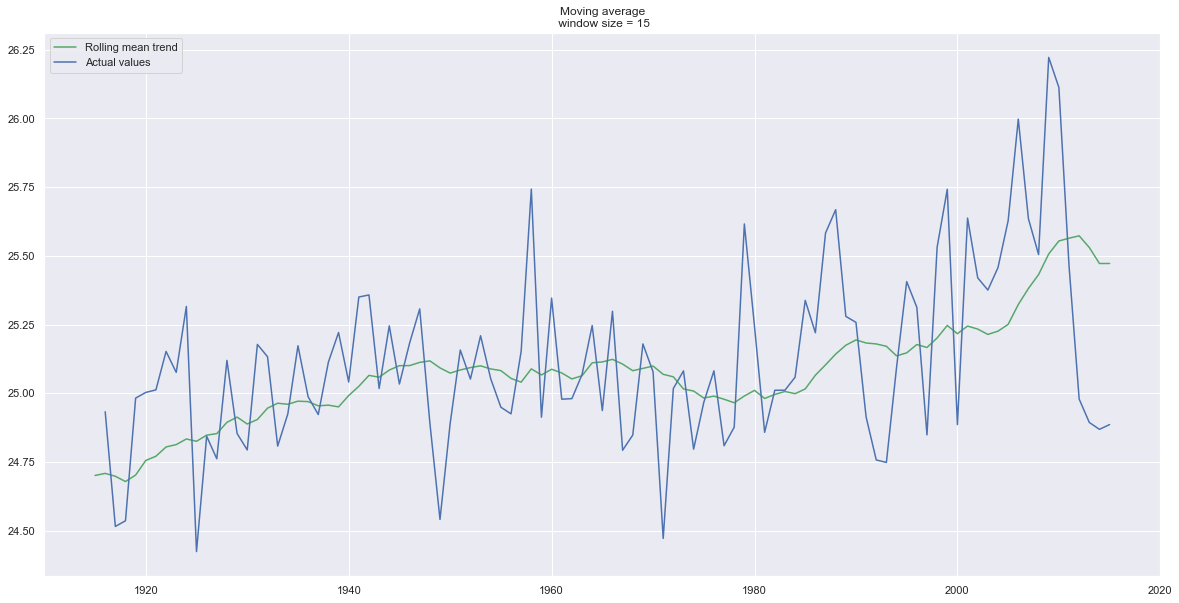

In [16]:
plotMovingAverage(df, 15) 

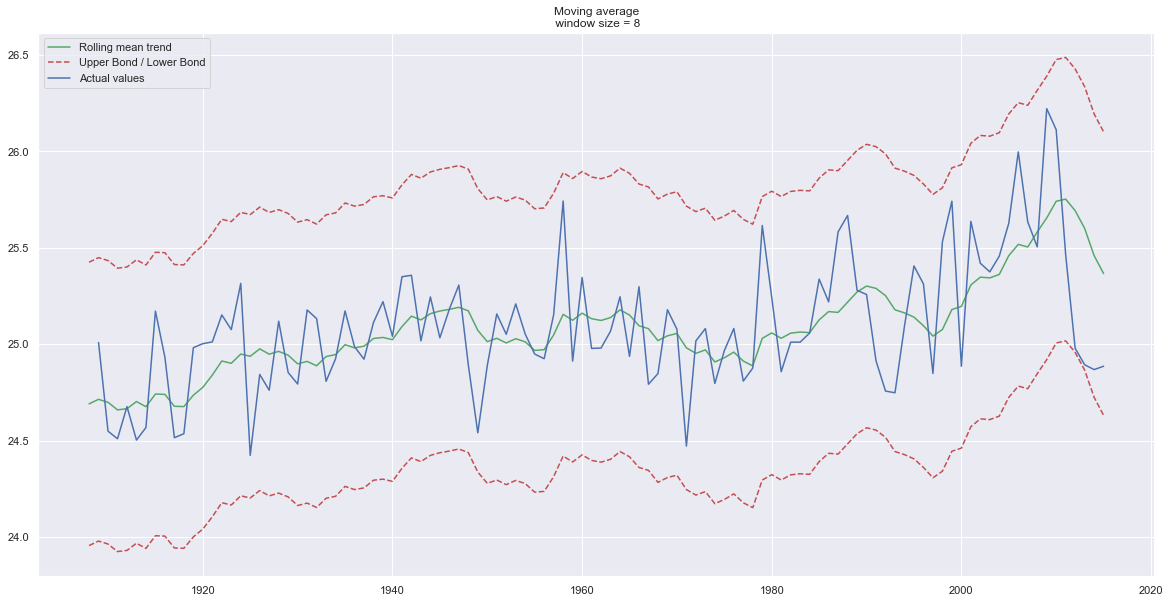

In [17]:
plotMovingAverage(df, 8, plot_intervals=True,plot_anomalies=True)